In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Simplest possible use of RNN?

In [ ]:
data = np.sin(np.linspace(0, 10, 100))

# create sequences: use past values to predict next value
def create_sequences(data, seq_length=10):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i+seq_length])
        ys.append(data[i+seq_length])
    return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)

X, y = create_sequences(data)
X = X.unsqueeze(-1)  # Shape: [samples, seq_length, 1] 1 is number of features

# define simple RNN model
rnn = nn.RNN(input_size=1, hidden_size=64, batch_first=True)
fc = nn.Linear(64, 1)

# train
optimizer = torch.optim.Adam(list(rnn.parameters())+list(fc.parameters()), lr=0.01)
#optimizer = torch.optim.Adam(rnn.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(100):
    #pred = model(X)
    out, _ = rnn(X)
    pred = fc(out[:, -1, :])  # Use last time step
    
    #pred = rnn(X)[0][:,-1,:]
    loss = criterion(pred.squeeze(), y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 5. Predict
rnn.eval()
with torch.no_grad():
    #predictions = model(X).squeeze()
    out, _ = rnn(X)
    predictions = fc(out[:, -1, :]).squeeze()

    # predict without hidden dims and fully connected layer
    #predictions = rnn(X)[0][:,-1,:]

In [152]:
X.shape

torch.Size([90, 10, 1])

In [153]:
out.shape, pred.shape

(torch.Size([90, 10, 64]), torch.Size([90, 1]))

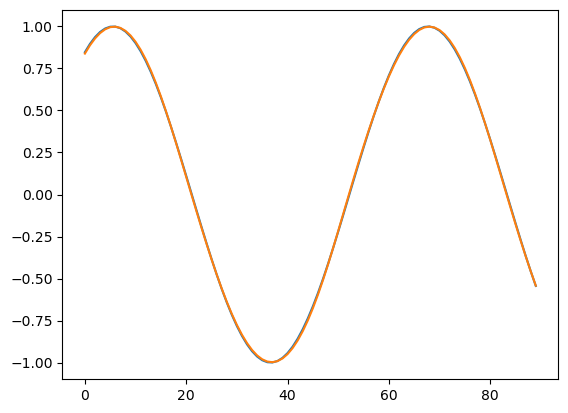

In [154]:
plt.plot(y)
plt.plot(predictions)